# Generate Transition Plots

In [1]:
import os
import sys

sys.path.append('..')
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import torch
import numpy as np
import random
import pylab as plt
import tqdm

from coronal_diffusion import dataset
from coronal_diffusion import visualization_tools as vt
from coronal_diffusion import sampler

import config

/home/dedasilv/micromamba/envs/coronal-diffusion/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/dedasilv/micromamba/envs/coronal-diffusion/lib/python3.11/site-packages/ai/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
def set_seeds(seed):
    torch.use_deterministic_algorithms(True)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

In [3]:
set_seeds(0)

In [4]:
os.chdir('..')
print('Current directory is:', os.getcwd())

Current directory is: /home/dedasilv/coronal-diffusion-modeling


In [5]:
sampling_data = sampler.load_sampling_data()

In [6]:
#weights_file = 'checkpoints/experiment54-hemi_16.pth'
weights_file = 'checkpoints/experiment59-cs-fix-and-context-scaling_16.pth'

In [7]:
img_max, (G_max, H_max) = sampler.sample(
    weights_file=weights_file,
    sampling_data=sampling_data,
    context=(50, 50, 10, 10, 1, -1),
    method='ddpm',
)

Denoising Step 1                 
Fitting spherical harmonics (45)


In [8]:
img_min, (G_min, H_min) = sampler.sample(
    weights_file=weights_file,
    sampling_data=sampling_data,
    context=(0, 0, 0, 0, 1, -1),
    method='ddpm',
)

Denoising Step 1                 
Fitting spherical harmonics (45)


In [9]:
def plot_img(img, title):
    fig, axes = plt.subplots(4, 4, sharex=True, sharey=True, figsize=(12, 8))
    
    for i in range(img.shape[0]):
        axes.flatten()[i].imshow(img[i], origin='lower', cmap='coolwarm')
        axes.flatten()[i].axis('off')
        axes.flatten()[i].set_title(f'r = {config.radii[i]:.2f} $R_\\odot$')
    
    fig.suptitle(title, fontsize=24)
    return fig

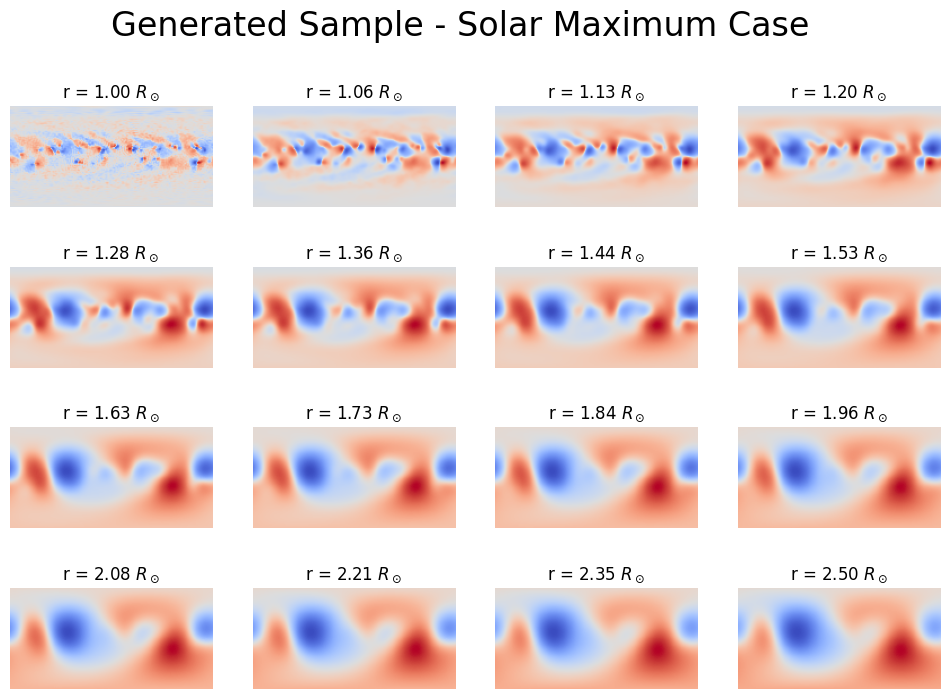

In [10]:
fig = plot_img(img_max, 'Generated Sample - Solar Maximum Case')
fig.savefig('plots/paper/sample_solar_max_2d.png', dpi=300)

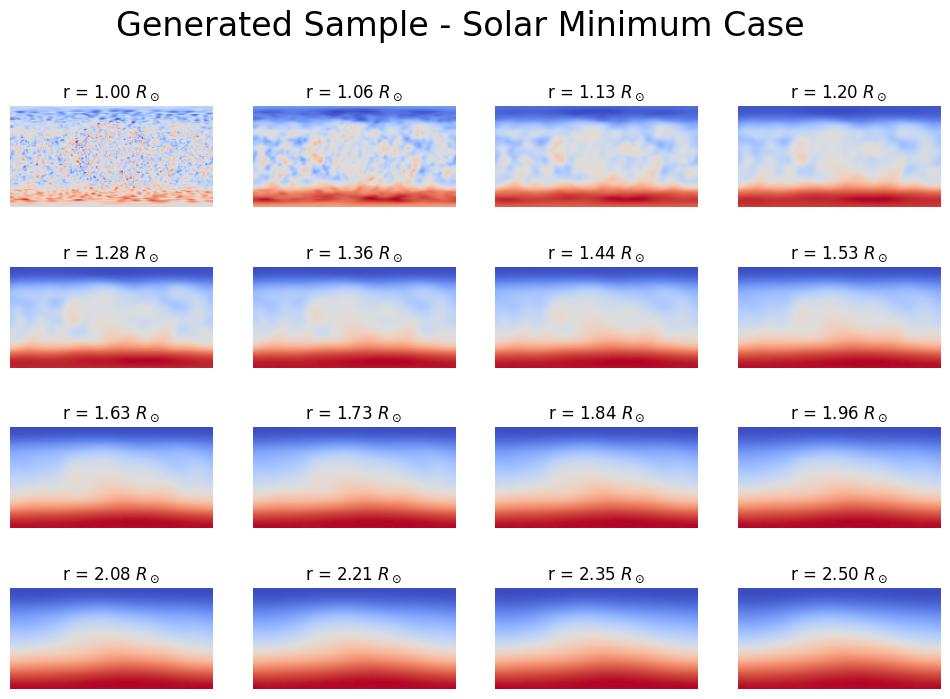

In [11]:
fig = plot_img(img_min, 'Generated Sample - Solar Minimum Case')
fig.savefig('plots/paper/sample_solar_min_2d.png', dpi=300)

In [12]:
from coronal_diffusion import visualization_tools as vt

In [13]:
vis = vt.Visualizer(G_min, H_min)
fig = vis.visualize_field_lines(r=1.1, grid_density=40)
fig.write_image(f'plots/paper/sample_solar_min_3d.png', width=800, height=600)
fig.data = []

In [14]:
vis = vt.Visualizer(G_max, H_max)
fig = vis.visualize_field_lines(r=1.1, grid_density=40)
fig.write_image(f'plots/paper/sample_solar_max_3d.png', width=800, height=600)
fig.data = []

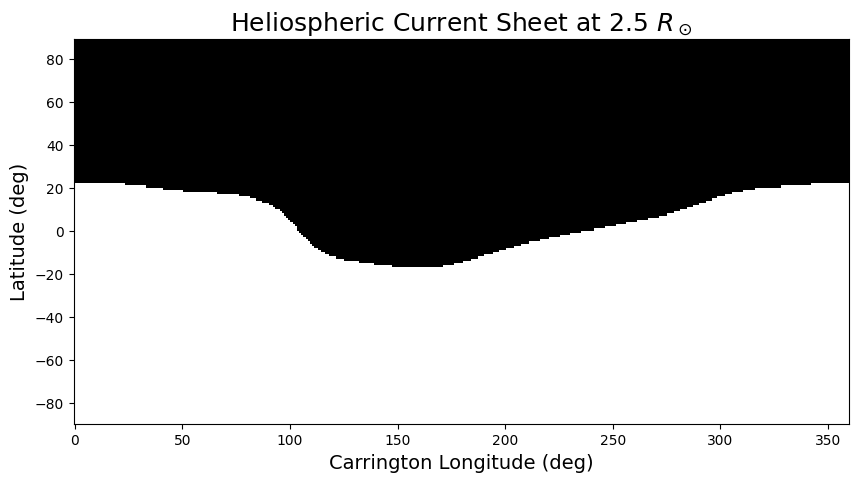

In [15]:
vis = vt.Visualizer(G_min, H_min)
vis.plot_current_sheet(r=2.5)
plt.xlabel('Carrington Longitude (deg)', fontsize=14)
plt.ylabel('Latitude (deg)', fontsize=14)
plt.title('Heliospheric Current Sheet at 2.5 $R_\\odot$', fontsize=18)
plt.savefig('plots/paper/sample_solar_min_hcs.png', dpi=300)

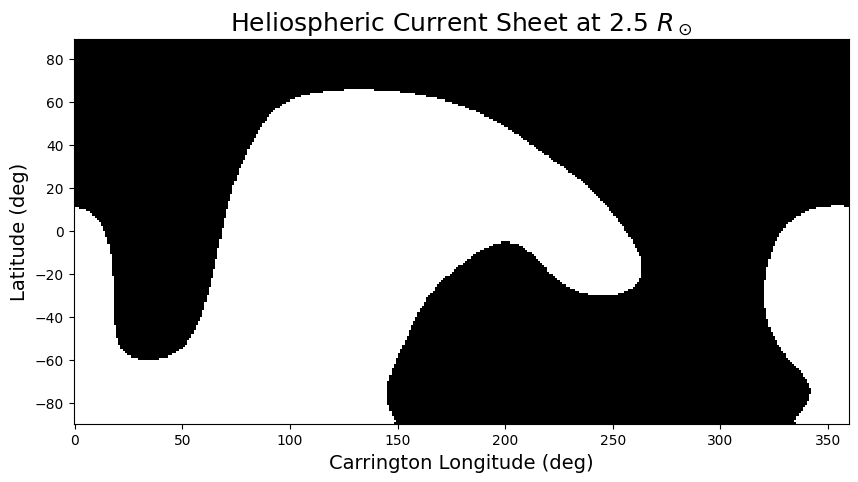

In [16]:
vis = vt.Visualizer(G_max, H_max)
vis.plot_current_sheet(r=2.5)
plt.xlabel('Carrington Longitude (deg)', fontsize=14)
plt.ylabel('Latitude (deg)', fontsize=14)
plt.title('Heliospheric Current Sheet at 2.5 $R_\\odot$', fontsize=18)
plt.savefig('plots/paper/sample_solar_max_hcs.png', dpi=300)

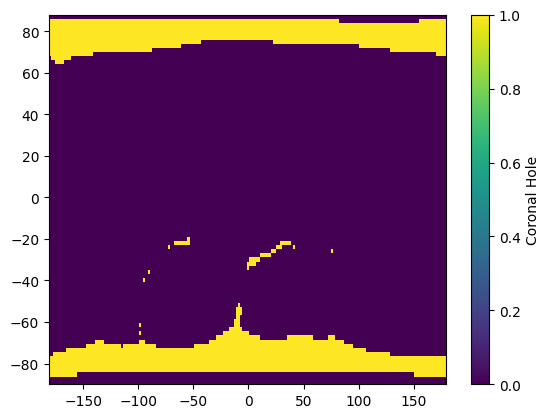

In [17]:
import importlib
importlib.reload(vt)
vis = vt.Visualizer(G_min, H_min)
vis.plot_coronal_holes(180, r=1.1)

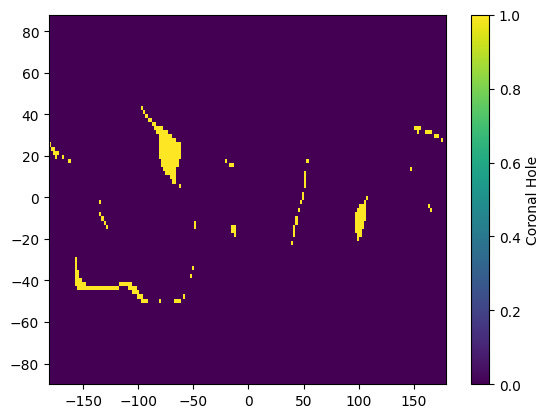

In [18]:
import importlib
importlib.reload(vt)
vis = vt.Visualizer(G_max, H_max)
vis.plot_coronal_holes(180, r=1.1)